In [1]:
%matplotlib inline
# changed from %matplotlib notebook as graphs werent being plotted 

In [2]:
from Bio.Align import PairwiseAligner, substitution_matrices
from Bio.Seq import Seq 
from Bio.SeqRecord import SeqRecord
from Bio import SeqIO
import numpy as np
from numpy import random as rd
from matplotlib import pyplot as plt

import os
import pickle
from matplotlib.ticker import MaxNLocator, ScalarFormatter, FormatStrFormatter
from matplotlib.ticker import LinearLocator
FIGSIZE = (4.5,3)
DPI = 300
N_TICKS = 3

In [3]:
from src.discrimalign import discrimalign
from src.logit_link import logit_partial_scores
from src.optimization import create_powerstep, create_constant_step

# Data

In [4]:
from miRBench.dataset import list_datasets, get_dataset_df

In [5]:
hejret_train = get_dataset_df(list_datasets()[0], split="train")
hejret_test = get_dataset_df(list_datasets()[0], split="test")

Using cached dataset /home/mciach/.miRBench/datasets/14501607/AGO2_CLASH_Hejret2023/train/dataset.tsv
Using cached dataset /home/mciach/.miRBench/datasets/14501607/AGO2_CLASH_Hejret2023/test/dataset.tsv


In [6]:
mirlist = hejret_train['noncodingRNA']
mirlist = [Seq(seq) for seq in mirlist]
genelist = hejret_train['gene']
genelist = [Seq(seq).reverse_complement() for seq in genelist]

# Optimization

### General matrix, affine gap penalty

In [7]:
true_gapopen = -1.2
true_gapext = -0.1
true_substitution = substitution_matrices.Array(alphabet='ACTG', 
                                          data=np.array([
                                              [1, -0.3, -1, -0.8], 
                                              [-0.6, 1.2, -0.3, -1], 
                                              [-1.2, -0.4, 1, -0.8], 
                                              [-0.4, -1.4, -0.9, 1.3]]))

In [8]:
aligner = PairwiseAligner()
aligner.mode = 'local'
aligner.open_gap_score = true_gapopen
aligner.extend_gap_score = true_gapext
aligner.substitution_matrix = true_substitution

In [9]:
scores = np.array([aligner.score(a, b) for a, b in zip(mirlist, genelist)])

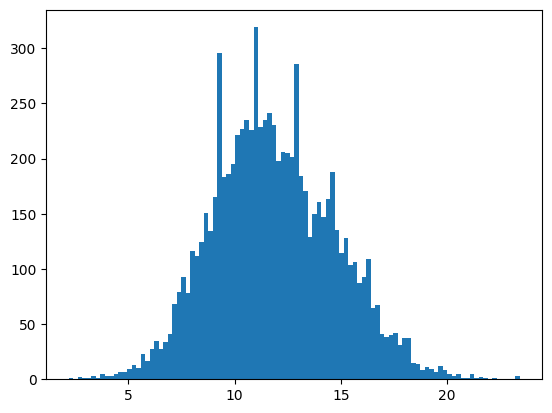

In [10]:
plt.figure()
plt.hist(scores, bins=100)
plt.show()

In [11]:
true_alpha = -12
logit_scores = logit_partial_scores(scores, true_alpha)

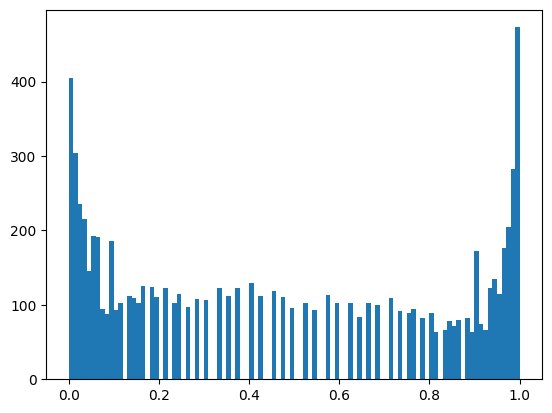

In [12]:
plt.figure()
plt.hist(logit_scores, bins=100)
plt.show()

In [13]:
labels = rd.rand(len(mirlist))
labels = labels <= logit_scores
true_logL = np.sum(np.log(logit_scores[labels]))+np.sum(np.log(1-logit_scores[~labels]))
print('Sum of log-logit scores:', np.sum(np.log(logit_scores)))
print('True LogL:', true_logL)

Sum of log-logit scores: -11654.43085041492
True LogL: -3031.030850414926


In [154]:
#const_step = create_constant_step(0.00005)
powerstep = create_powerstep(0.00005, power=0.8, burnin=0)
# powerstep = create_powerstep(0.00002, power=-0.1, burnin=0)

In [157]:
NITER = 200 ## original 200 

In [158]:
params = discrimalign(mirlist, genelist, labels, 
                    stepfunction=const_step,
                    aligner_mode='local',
                    substitution_mode='general',
                    gap_mode='affine', 
                    stochastic_factor=0.01,
                    verbose=True, max_iter=NITER,
                    num_threads = 24)

Alphabet:
ACGT
Initial parameters:
{'alpha': -9.34817531931555, 'substitution_matrix': Array([[ 0.85625693, -0.43579092, -0.56327259, -0.82773493],
       [-0.48162464,  1.06023954, -0.82048882, -0.39489534],
       [-0.55806772, -0.77647697,  1.11294884, -0.59164245],
       [-0.88207055, -0.47527676, -0.69710259,  0.81727624]],
         alphabet='ACGT'), 'open_gap_score': -1.1688765114115414, 'extend_gap_score': -0.09347579606232079}
Start of iteration 0
Current alpha: -9.34817531931555
Current logL: -3094.900786195941
Updated alpha: -9.61302535046517
Updated logL: -3058.2856501736833
New subgradient:
{'Substitutions': Array([[ 79.30130737,  29.86903072,  -1.87657921,  -2.47323601],
       [-17.66362644,  78.19904491, -11.83419866,  49.20346692],
       [ 17.6957249 , -27.16384472, 115.85057571, -16.36109943],
       [  0.72475893,  16.3680655 ,   1.57049427, 114.14454235]],
         alphabet='ACGT'), 'Gap opens': 131.31284267473902, 'Gap extends': 335.9679479417064}
Stepsize: 5e-05


Current alpha: -9.957809628548393
Current logL: -3058.7628464166096
Updated alpha: -10.101406961477714
Updated logL: -3048.134733428081
New subgradient:
{'Substitutions': Array([[ 48.06290234,  32.29806368,  -2.25946572,  -5.32524284],
       [ -7.06956585,  56.79980414,  -9.99082198,  44.65953891],
       [ 15.88168144, -22.29438014,  59.01113264, -10.57839319],
       [ -6.92739788,  17.54465492,  -0.16363177,  49.7483632 ]],
         alphabet='ACGT'), 'Gap opens': 50.86147031977973, 'Gap extends': -162.32813159140468}
Stepsize: 5e-05
Gap open step: 0.0025430735159889866
Gap extend step: -0.008116406579570235
New parameters:
{'alpha': -10.101406961477714, 'substitution_matrix': Array([[ 0.88069574, -0.42376915, -0.56377958, -0.82909644],
       [-0.48756717,  1.08769183, -0.82456926, -0.37594978],
       [-0.55135479, -0.7867651 ,  1.14507508, -0.59629342],
       [-0.88410372, -0.46861435, -0.69651447,  0.84856001]],
         alphabet='ACGT'), 'open_gap_score': -1.1722367950294619, 

Current alpha: -10.375026345262636
Current logL: -3041.107197685314
Updated alpha: -10.401346357673429
Updated logL: -3040.7553905007835
New subgradient:
{'Substitutions': Array([[ 39.03695347,  29.41159467, -10.0248744 , -11.49792151],
       [ -6.01054038,  38.82597924,  -7.68863678,  41.4575747 ],
       [ 18.61238914, -21.80807959,  41.79858862, -20.71243629],
       [ -6.63751636,  14.51681878,   2.73371773,  41.56322071]],
         alphabet='ACGT'), 'Gap opens': 31.602987892874324, 'Gap extends': 35.56875443724025}
Stepsize: 5e-05
Gap open step: 0.0015801493946437162
Gap extend step: 0.0017784377218620126
New parameters:
{'alpha': -10.401346357673429, 'substitution_matrix': Array([[ 0.89889028, -0.41152653, -0.56565455, -0.83278935],
       [-0.49069799,  1.10719665, -0.827419  , -0.35848055],
       [-0.54428507, -0.79570873,  1.16640891, -0.60362172],
       [-0.88649922, -0.46220894, -0.69591076,  0.86801301]],
         alphabet='ACGT'), 'open_gap_score': -1.1528503750352186, 

Current alpha: -10.623610998452211
Current logL: -3037.5685844248605
Updated alpha: -10.66294603975138
Updated logL: -3036.7875615573694
New subgradient:
{'Substitutions': Array([[ 23.91773453,  25.04315223,  -7.08975652,  -9.74045235],
       [ -9.58692025,  32.5475293 ,  -6.16718689,  35.42238554],
       [ 20.43926965, -22.27744586,  27.39748426, -20.65793302],
       [ -8.76392812,   6.56683109,   0.06053688,  21.82966642]],
         alphabet='ACGT'), 'Gap opens': 15.239001834353022, 'Gap extends': -64.0921646641222}
Stepsize: 5e-05
Gap open step: 0.0007619500917176511
Gap extend step: -0.0032046082332061097
New parameters:
{'alpha': -10.66294603975138, 'substitution_matrix': Array([[ 0.91212563, -0.40059419, -0.5691613 , -0.836823  ],
       [-0.49358578,  1.12115316, -0.83058994, -0.34291892],
       [-0.53615327, -0.80494705,  1.18059696, -0.61167589],
       [-0.88934105, -0.45763541, -0.69557278,  0.88090491]],
         alphabet='ACGT'), 'open_gap_score': -1.1424285848605789, 

Current alpha: -10.75933332188909
Current logL: -3040.622581569365
Updated alpha: -10.862576294748317
Updated logL: -3035.252987827761
New subgradient:
{'Substitutions': Array([[ 15.76606823,  20.58092435, -11.6313237 ,  -7.60776654],
       [ -4.00731406,  13.87216784,  -6.93598221,  28.0662996 ],
       [ 14.23510544, -21.86228737,  17.57122677, -19.62004048],
       [-11.52920431,  10.93300609,  -1.75394634,   8.11969839]],
         alphabet='ACGT'), 'Gap opens': -7.453385617153408, 'Gap extends': -167.84531416524635}
Stepsize: 5e-05
Gap open step: -0.00037266928085767046
Gap extend step: -0.008392265708262318
New parameters:
{'alpha': -10.862576294748317, 'substitution_matrix': Array([[ 0.92166413, -0.39180773, -0.57352922, -0.84031507],
       [-0.49631066,  1.12960352, -0.83349695, -0.32972736],
       [-0.53028783, -0.81338522,  1.19051166, -0.61999033],
       [-0.89390672, -0.45432043, -0.69648183,  0.88906558]],
         alphabet='ACGT'), 'open_gap_score': -1.1395049461769584

...

Current alpha: -11.384110171909954
Current logL: -3025.636887983394
Updated alpha: -11.426129180508541
Updated logL: -3024.7715621670727
New subgradient:
{'Substitutions': Array([[ -0.39427713,   2.96586191,  -3.30727391,  -4.17708773],
       [ -0.39953485,   0.62593994,  -5.35144916,   5.41800093],
       [  0.2786795 , -12.93500185,   2.76685135,  -7.95102054],
       [ -7.05583715,   4.00462801,  -2.97333259,  -2.11618177]],
         alphabet='ACGT'), 'Gap opens': -6.767873709806368, 'Gap extends': -75.25629572991099}
Stepsize: 5e-05
Gap open step: -0.0003383936854903184
Gap extend step: -0.0037628147864955494
New parameters:
{'alpha': -11.426129180508541, 'substitution_matrix': Array([[ 0.96621614, -0.32964238, -0.62293205, -0.87805686],
       [-0.52317492,  1.17203836, -0.8651291 , -0.22806947],
       [-0.49710967, -0.92509208,  1.23963874, -0.71031284],
       [-0.96013306, -0.42975349, -0.70437056,  0.9313824 ]],
         alphabet='ACGT'), 'open_gap_score': -1.174362269418512

Current alpha: -11.402775798802889
Current logL: -3024.5565657849024
Updated alpha: -11.414458509260449
Updated logL: -3024.489800511539
New subgradient:
{'Substitutions': Array([[  1.38627231,   1.59678466,  -2.01565688,  -4.8512507 ],
       [ -2.05895942,   0.27885838,  -4.15158281,   2.05329661],
       [ -1.8997009 , -10.09309921,  -2.5677729 ,  -8.86274143],
       [ -7.71993594,   0.60228437,  -1.62026198,   3.78831971]],
         alphabet='ACGT'), 'Gap opens': -6.062108457552343, 'Gap extends': -33.008367717781546}
Stepsize: 5e-05
Gap open step: -0.00030310542287761717
Gap extend step: -0.0016504183858890775
New parameters:
{'alpha': -11.414458509260449, 'substitution_matrix': Array([[ 0.96736057, -0.32887624, -0.6240365 , -0.8798639 ],
       [-0.52393533,  1.172769  , -0.86689287, -0.22708204],
       [-0.49777163, -0.92937522,  1.24022786, -0.71391426],
       [-0.96324162, -0.42943088, -0.70491222,  0.93260075]],
         alphabet='ACGT'), 'open_gap_score': -1.1752832081456

Current alpha: -11.400466645962686
Current logL: -3025.4969054098915
Updated alpha: -11.445318402085391
Updated logL: -3024.5119420557508
New subgradient:
{'Substitutions': Array([[ -3.51756806,   2.22159746,  -2.22875697,  -3.54315405],
       [  0.22008876,   1.73501731,  -5.22824195,   3.9269764 ],
       [ -0.18927791, -10.90280058,   2.7996178 ,  -6.55833046],
       [ -6.26566117,   3.37321537,  -4.17128866,  -4.15300452]],
         alphabet='ACGT'), 'Gap opens': -9.68127036530623, 'Gap extends': -81.25192650869106}
Stepsize: 5e-05
Gap open step: -0.0004840635182653115
Gap extend step: -0.004062596325434553
New parameters:
{'alpha': -11.445318402085391, 'substitution_matrix': Array([[ 0.9683566 , -0.32828769, -0.62511709, -0.8816915 ],
       [-0.52460232,  1.1736372 , -0.86863471, -0.22636394],
       [-0.49855741, -0.93338658,  1.24112457, -0.71736112],
       [-0.96624185, -0.42906924, -0.70553596,  0.93329737]],
         alphabet='ACGT'), 'open_gap_score': -1.1763155737208708

Current alpha: -11.420372254850074
Current logL: -3024.252203776092
Updated alpha: -11.426732204900159
Updated logL: -3024.2324405518234
New subgradient:
{'Substitutions': Array([[  1.52728743,   1.35328463,  -2.78393676,  -4.45248036],
       [ -0.88263726,   0.28394053,  -3.64387326,   1.5678008 ],
       [ -1.97325566, -12.66732268,  -0.33621263,  -6.17609741],
       [ -5.93534741,   0.66923931,  -1.73726349,   2.09763835]],
         alphabet='ACGT'), 'Gap opens': -4.546523257052431, 'Gap extends': -25.81798748089347}
Stepsize: 5e-05
Gap open step: -0.00022732616285262158
Gap extend step: -0.0012908993740446736
New parameters:
{'alpha': -11.426732204900159, 'substitution_matrix': Array([[ 0.96969674, -0.3279672 , -0.62620034, -0.88355393],
       [-0.52526209,  1.1742933 , -0.87022421, -0.22605387],
       [-0.49940452, -0.93807802,  1.24146495, -0.72051773],
       [-0.96861574, -0.4289733 , -0.70599331,  0.93400205]],
         alphabet='ACGT'), 'open_gap_score': -1.17690070379031

Current alpha: -11.425732885679734
Current logL: -3024.1598171686487
Updated alpha: -11.434915433634742
Updated logL: -3024.118635984642
New subgradient:
{'Substitutions': Array([[  1.38453568,   0.27703811,  -2.95714889,  -5.22588411],
       [ -1.03936867,   1.47263823,  -3.55713578,   1.70061748],
       [ -2.68791321, -12.08801578,   0.95755439,  -6.57225467],
       [ -4.70919273,   0.63812861,  -2.89299272,   0.39653263]],
         alphabet='ACGT'), 'Gap opens': -2.2832817935793264, 'Gap extends': -18.233268661224006}
Stepsize: 5e-05
Gap open step: -0.00011416408967896632
Gap extend step: -0.0009116634330612003
New parameters:
{'alpha': -11.434915433634742, 'substitution_matrix': Array([[ 0.97068836, -0.3277957 , -0.62738406, -0.88543804],
       [-0.52600844,  1.17508331, -0.8717004 , -0.22559078],
       [-0.50032786, -0.94281279,  1.24222063, -0.72331122],
       [-0.97064863, -0.42902625, -0.70665302,  0.93433107]],
         alphabet='ACGT'), 'open_gap_score': -1.177496349866

In [133]:
print(params['final_loglik'])

-3021.485109473373


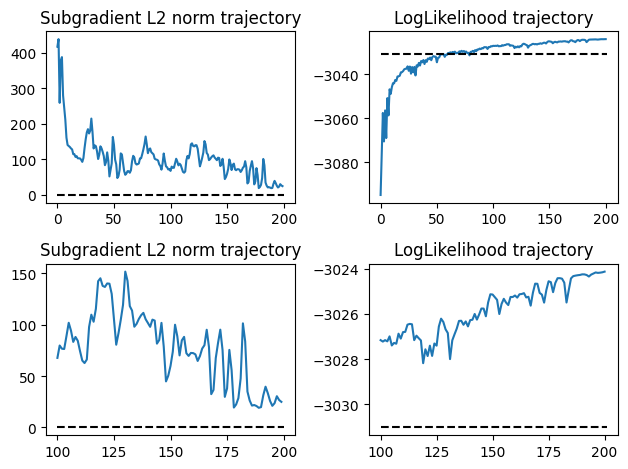

In [159]:
plt.figure()
plt.subplot(221)
plt.plot(np.arange(NITER), params['subgradient_l2_trajectory'])
plt.plot([0, NITER], [0, 0], 'k--')
plt.title('Subgradient L2 norm trajectory')


plt.subplot(222)
plt.plot(np.arange(NITER+1), params['loglik_trajectory'])
plt.plot([0, NITER+1], [true_logL, true_logL], 'k--')
plt.title('LogLikelihood trajectory')


plt.subplot(223)
plt.plot(np.arange(NITER//2, NITER), params['subgradient_l2_trajectory'][NITER//2:])
plt.plot([NITER//2, NITER], [0, 0], 'k--')
plt.title('Subgradient L2 norm trajectory')

plt.subplot(224)
plt.plot(np.arange(NITER//2, NITER+1), params['loglik_trajectory'][NITER//2:])
plt.plot([NITER//2, NITER+1], [true_logL, true_logL], 'k--')
plt.title('LogLikelihood trajectory')

plt.tight_layout()

In [104]:
print(true_gapopen, params['open_gap_score'])
print(true_gapext, params['extend_gap_score'])
print(true_alpha, params['alpha'])
true_subs_vector = []
param_subs_vector = []
for char1 in true_substitution.alphabet:
    for char2 in true_substitution.alphabet:
        true_v = true_substitution[char1, char2]
        true_subs_vector.append(true_v)
        estim_v = params['substitution_matrix'][char1, char2]
        param_subs_vector.append(estim_v)
        print(char1, char2, true_v, estim_v)
        
print(np.corrcoef(true_subs_vector, param_subs_vector))
print(np.mean(np.abs(np.array(true_subs_vector)- np.array(param_subs_vector)))) # mean asolute error calculation vs correlation boxplot for 20 replicates (data already present) 

-1.2 -1.1556308612920656
-0.1 -0.10279441418774404
-12 -11.294019977057598
A A 1.0 0.9526180508203654
A C -0.3 -0.343352068455368
A T -1.0 -0.8592865786438292
A G -0.8 -0.6069735597084411
C A -0.6 -0.5139361956622468
C C 1.2 1.1601338994662656
C T -0.3 -0.25703058519635347
C G -1.0 -0.8495307470960737
T A -1.2 -0.9294541686718288
T C -0.4 -0.4419619567831284
T T 1.0 0.9209991824991394
T G -0.8 -0.6985483451567592
G A -0.4 -0.49534324163694593
G C -1.4 -0.8758394849244922
G T -0.9 -0.6788262922641982
G G 1.3 1.2260221475357513
[[1.         0.98984183]
 [0.98984183 1.        ]]
0.1344661268268561


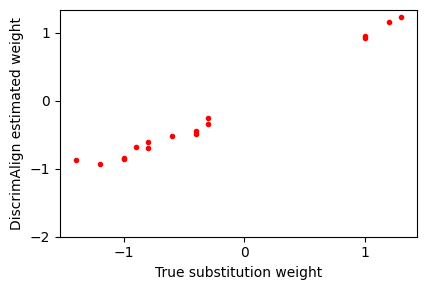

In [148]:
plt.figure(figsize=FIGSIZE)

plt.plot(true_subs_vector, param_subs_vector, 'r.')

plt.xlabel("True substitution weight")
plt.ylabel("DiscrimAlign estimated weight")

plt.tight_layout()
ax = plt.gca()
xmin, xmax = ax.get_xlim()
ax.set_xticks(np.linspace(-2, 1, 4))
ax.set_xlim(xmin, xmax)

ax.set_yticks(np.linspace(*ax.get_ylim(), 4, dtype=int))
#plt.savefig("results/general/true_vs_estimated_submatrix.png", dpi=DPI)

In [21]:
from src.optimization import get_initial_estimate

In [22]:
get_initial_estimate(params['alignments'], labels, substitution_mode='general', gap_mode='affine',
                     alphabet=true_substitution.alphabet)

{'alpha': -11.319469350182189,
 'substitution_matrix': Array([[ 0.97151268, -0.28006895, -0.91764371, -0.60616896],
        [-0.55387567,  1.18118504, -0.23006368, -0.95709479],
        [-0.98026659, -0.44560547,  0.93363099, -0.7290584 ],
        [-0.52130976, -1.02985083, -0.71154299,  1.24596277]],
          alphabet='ACTG'),
 'open_gap_score': -1.2085447094478856,
 'extend_gap_score': -0.10142352373039719}

In [23]:
true_substitution

Array([[ 1. , -0.3, -1. , -0.8],
       [-0.6,  1.2, -0.3, -1. ],
       [-1.2, -0.4,  1. , -0.8],
       [-0.4, -1.4, -0.9,  1.3]],
         alphabet='ACTG')

In [24]:
estim_substitution = true_substitution.copy()
for char1 in true_substitution.alphabet:
    for char2 in true_substitution.alphabet:
        estim_substitution[char1, char2] = params['substitution_matrix'][char1, char2]

In [25]:
estim_substitution

Array([[ 0.87188019, -0.42748619, -0.82853544, -0.56380197],
       [-0.48509806,  1.07799254, -0.38272545, -0.82276729],
       [-0.88298951, -0.47110282,  0.83803455, -0.69671576],
       [-0.55416011, -0.78263337, -0.59502556,  1.13461148]],
         alphabet='ACTG')

### Parameter Convergence Experiment


In [160]:
theta = params['theta_trajectory']
theta_star = np.concatenate([np.array(true_substitution).flatten(), [true_gapopen, true_gapext]]) ## what we try to estimate
loglik = np.array(params['loglik_trajectory'])

# ||theta_n - theta*||
theta_diff = []
for theta_n in theta: 
    diff = np.linalg.norm(theta_n - theta_star)
    theta_diff.append(diff)

theta_diff = np.array(theta_diff)

In [161]:
theta[49]

array([ 0.93542224, -0.37656661, -0.582589  , -0.84721341, -0.50190084,
        1.14251331, -0.83837563, -0.30737319, -0.52010424, -0.82960647,
        1.20404304, -0.63565964, -0.90297315, -0.45099185, -0.69700942,
        0.90051169, -1.14192963, -0.10355703])

In [162]:
theta[4]

array([ 0.86872044, -0.43002359, -0.56336234, -0.82805   , -0.48486013,
        1.07477515, -0.82269183, -0.38554036, -0.55450184, -0.7818764 ,
        1.13042216, -0.59407635, -0.88282348, -0.47154408, -0.69652961,
        0.83434506, -1.18096981, -0.09305544])

In [163]:
theta_star

array([ 1. , -0.3, -1. , -0.8, -0.6,  1.2, -0.3, -1. , -1.2, -0.4,  1. ,
       -0.8, -0.4, -1.4, -0.9,  1.3, -1.2, -0.1])

In [164]:
diff_array = np.zeros((len(theta_star), NITER+1))
diff_array.shape

(18, 201)

In [165]:
for i, theta_n in enumerate(theta): 
    d = theta_star - theta_n 
    diff_array[..., i] = d

In [166]:
diff_array.shape

(18, 201)

In [167]:
theta_star.shape

(18,)

In [168]:
theta_star[12]

-0.4

In [169]:
true_substitution

Array([[ 1. , -0.3, -1. , -0.8],
       [-0.6,  1.2, -0.3, -1. ],
       [-1.2, -0.4,  1. , -0.8],
       [-0.4, -1.4, -0.9,  1.3]],
         alphabet='ACTG')

In [170]:
theta[50][12]

-0.9035359327138353

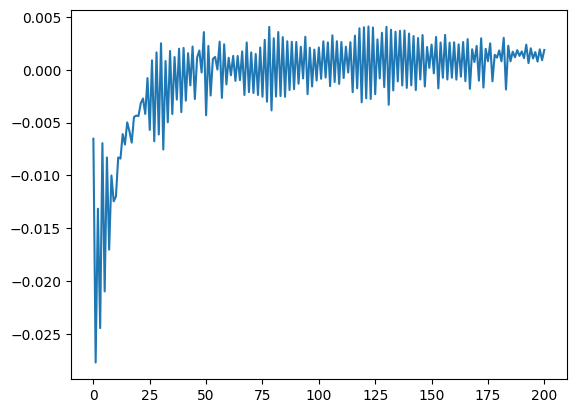

In [171]:
plt.figure()
plt.plot(range(NITER+1), diff_array[17,:])

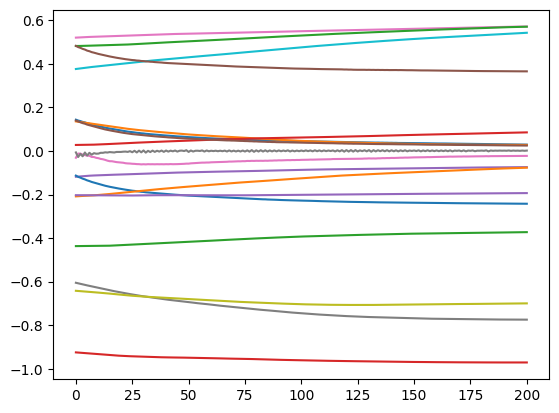

In [172]:
plt.figure()
for i in range(18): 
    plt.plot(range(NITER+1), diff_array[i,:])

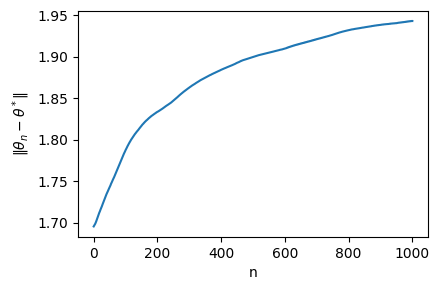

In [150]:
# ||theta_n - theta*|| vs n
plt.figure(figsize=FIGSIZE)

plt.plot(range(len(theta_diff)), theta_diff)

plt.xlabel("n")
plt.ylabel(r"$\|\theta_n - \theta^*\|$")

plt.tight_layout()
plt.show()

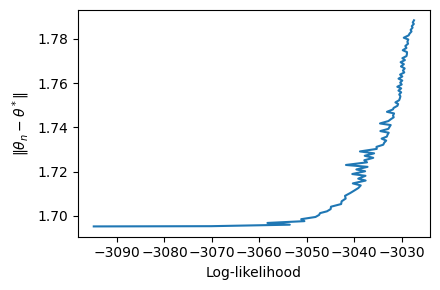

In [127]:
# ||theta_n - theta*|| vs log-likelihood

plt.figure(figsize=FIGSIZE)

plt.plot(loglik, theta_diff)

plt.xlabel("Log-likelihood")
plt.ylabel(r"$\|\theta_n - \theta^*\|$")

plt.tight_layout()
plt.show()

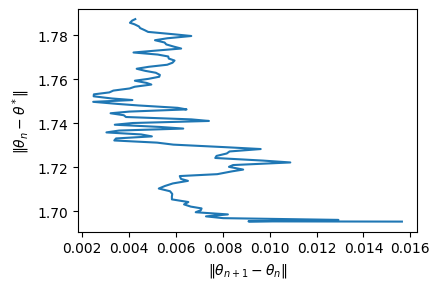

In [128]:
# ||theta_n - theta*|| vs ||theta_{n+1} - theta_n||
theta_nplusone = []
for n in range(len(theta) - 1):
    plusone = np.linalg.norm(theta[n+1] - theta[n])
    theta_nplusone.append(plusone)

theta_nplusone = np.array(theta_nplusone)

plt.figure(figsize=FIGSIZE)

plt.plot(theta_nplusone, theta_diff[:-1])

plt.xlabel(r"$\|\theta_{n+1} - \theta_n\|$")
plt.ylabel(r"$\|\theta_n - \theta^*\|$")

plt.tight_layout()
plt.show()

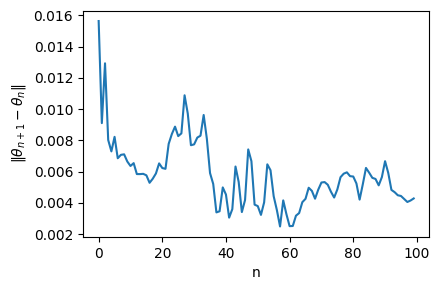

In [130]:
plt.figure(figsize=FIGSIZE)

plt.plot(range(NITER), theta_nplusone)

plt.xlabel('n')
plt.ylabel(r"$\|\theta_{n+1} - \theta_n\|$") 

plt.tight_layout()
plt.show()

### Step function parameters experiment

In [49]:
labels = rd.rand(len(mirlist)) <= logit_scores

In [50]:
true_logL = np.sum(np.log(logit_scores[labels]))+np.sum(np.log(1-logit_scores[~labels]))

In [51]:
steplengths = np.linspace(0.000005, 0.00005, num=10)
steplengths

array([5.0e-06, 1.0e-05, 1.5e-05, 2.0e-05, 2.5e-05, 3.0e-05, 3.5e-05,
       4.0e-05, 4.5e-05, 5.0e-05])

In [52]:
NITER = 200

In [53]:
# Get the iteration at which logL is hit (speed)
def get_logL__reached_iter(params, true_logL):
    for i, logL in enumerate(params['loglik_trajectory']):
        if logL >= true_logL:
            return i
    return None

In [54]:
# Get the value at the last iteration of the simulation
def get_final_val_avg(params):
    return np.mean(params['loglik_trajectory'][-20:])

In [55]:
pickle_path = "results/general/step_experiment_general.pkl"

if os.path.exists(pickle_path):
    with open(pickle_path, "rb") as f:
        saved = pickle.load(f)

    labels = saved["labels"]
    true_logL = saved["true_logL"]
    discrimalign_results_step = saved["discrimalign_results_step"]
    logL_reached_iters = saved["logL_reached_iters"]
    final_vals = saved["final_vals"]

else:
    
    labels = rd.rand(len(mirlist)) <= logit_scores
    true_logL = np.sum(np.log(logit_scores[labels]))+np.sum(np.log(1-logit_scores[~labels]))
    
    discrimalign_results_step = []

    logL_reached_iters = []
    final_vals = []

    for stepl in steplengths:
        const_step = create_constant_step(stepl)
        
        params = discrimalign(mirlist, genelist, labels, 
                        stepfunction=const_step,
                        aligner_mode='local',
                        substitution_mode='general', ## changed 
                        gap_mode = 'affine',
                        verbose=False, max_iter=NITER,
                        stochastic_factor=0.001,
                        num_threads = 16)
        discrimalign_results_step.append(params)

        logL_reached_iter = get_logL__reached_iter(params, true_logL)
        logL_reached_iters.append(logL_reached_iter if logL_reached_iter is not None else np.inf) # infinity so that they dont show on the scatter plot 

        final_val = get_final_val_avg(params)
        final_vals.append(final_val)

        if logL_reached_iter is not None:
            print(f"step {stepl:.2e}, surpassed logL at iteration {logL_reached_iter} and reached a maximum value of {final_val}")
        else:
            print(f"step {stepl:.2e} did NOT hit logL")
    
    with open(pickle_path, "wb") as f:
        pickle.dump(
            {
                "labels": labels,
                "true_logL": true_logL,
                "discrimalign_results_step": discrimalign_results_step,
                "logL_reached_iters": logL_reached_iters,
                "final_vals": final_vals,
                "steplengths": steplengths,
                "NITER": NITER,
            },
            f
        )

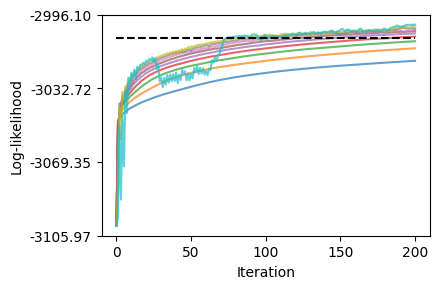

In [56]:
step_colors = plt.cm.tab10(np.linspace(0, 1, len(steplengths)))

plt.figure(figsize=FIGSIZE)
for params,color in zip(discrimalign_results_step, step_colors):
    plt.plot(np.arange(NITER+1), params['loglik_trajectory'],color = color, alpha=0.7)
plt.plot([0, NITER], [true_logL, true_logL], 'k--')

plt.xlabel("Iteration")
plt.ylabel("Log-likelihood")
ax = plt.gca()
ax.set_xticks(np.linspace(0, 200, 5, dtype=int))
ax.set_yticks(np.linspace(*ax.get_ylim(), 4))
ax.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))

plt.tight_layout()
plt.savefig("results/general/step_experiment_full_trajectories_general.png", dpi=DPI)

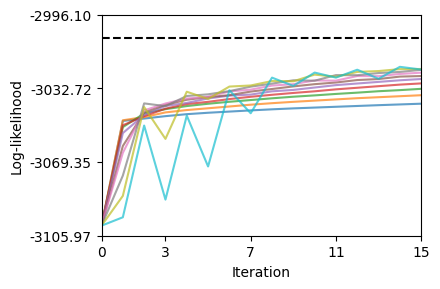

In [57]:
# zoom on start
plt.figure(figsize=FIGSIZE)
for params,color in zip(discrimalign_results_step, step_colors):
    plt.plot(np.arange(NITER+1), params['loglik_trajectory'],color = color, alpha=0.7)
plt.plot([0, NITER], [true_logL, true_logL], 'k--')

plt.xlim(0, 15)
plt.xlabel("Iteration")
plt.ylabel("Log-likelihood")
ax = plt.gca()
ax.set_xticks(np.linspace(0, 15, 5, dtype=int))
ax.set_yticks(np.linspace(*ax.get_ylim(), 4))
ax.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))

plt.tight_layout()
plt.savefig("results/general/step_experiment_zoom_start_general.png", dpi=DPI)

In [58]:
# # zoom where most trajectories hit logL
# plt.figure(figsize=FIGSIZE)
# for params,color in zip(discrimalign_results_step, step_colors):
#     plt.plot(np.arange(NITER+1), params['loglik_trajectory'],color = color, alpha=0.7)
# plt.plot([0, NITER], [true_logL, true_logL], 'k--')

# plt.xlim(25, NITER) 
# all_vals = np.concatenate([
#     np.array(p['loglik_trajectory'])[25:]
#     for p in discrimalign_results_step
# ])

# ymin, ymax = all_vals.min(), all_vals.max()
# plt.ylim(ymin, 0.9999 * ymax)
# plt.xlabel("Iteration")
# plt.ylabel("Log-likelihood")

# ax = plt.gca()
# ax.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))
# plt.tight_layout()
# plt.savefig("results/general/step_experiment_zoom_mid_general.png", dpi=DPI)

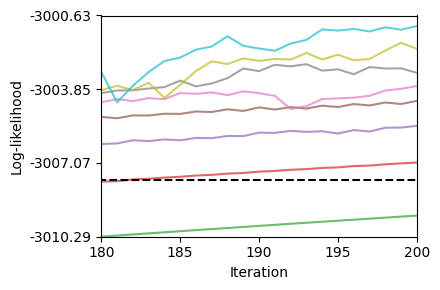

In [59]:
# zoom on the end of the iterations
plt.figure(figsize=FIGSIZE)

for params,color in zip(discrimalign_results_step, step_colors):
    plt.plot(np.arange(NITER+1), params['loglik_trajectory'],color = color, alpha=0.7)
    
plt.plot([0, NITER], [true_logL, true_logL], 'k--')


plt.xlim(NITER-20, NITER)

# collect only last 20 iterations
all_vals = np.concatenate([
    np.array(p['loglik_trajectory'])[NITER-20:]
    for p in discrimalign_results_step
])

#sort and drop lowest x % 
sorted_vals = np.sort(all_vals)
cutoff = int(0.2 * len(sorted_vals))  # remove lowest x%
trimmed_vals = sorted_vals[cutoff:]

ymin = trimmed_vals.min()
ymax = trimmed_vals.max()

pad = 0.05 * (ymax - ymin)

plt.ylim(ymin, ymax + pad)

ax = plt.gca()
ax.set_xticks(np.linspace(180, 200, 5, dtype=int))
ax.set_yticks(np.linspace(*ax.get_ylim(), 4))
ax.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))

plt.xlabel("Iteration")
plt.ylabel("Log-likelihood")

plt.tight_layout()
plt.savefig("results/general/step_experiment_zoom_end_general.png", dpi=DPI)

/tmp/ipykernel_50373/1231280037.py:18: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab10", len(unique_steps))


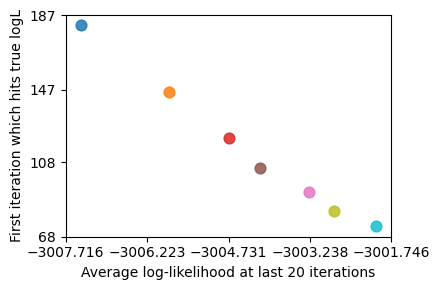

In [60]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import ScalarFormatter


plt.figure(figsize=FIGSIZE)

logL_reached_iters_arr = np.array(logL_reached_iters)
final_vals_arr = np.array(final_vals)
steplengths_arr = np.array(steplengths)

mask = np.isfinite(logL_reached_iters_arr)

# Get unique step sizes
unique_steps = np.sort(np.unique(steplengths_arr[mask]))

# Use a discrete colormap
cmap = plt.cm.get_cmap("tab10", len(unique_steps))

for i, s in enumerate(unique_steps):
    idx = (steplengths_arr == s) & mask

    plt.scatter(
        final_vals_arr[idx],
        logL_reached_iters_arr[idx],
        color=cmap(i),
        s=60,
        label=f"{s:.2e}",
        alpha=0.85
    )

plt.ylabel("First iteration which hits true logL")
plt.xlabel("Average log-likelihood at last 20 iterations")


ax = plt.gca()
xmin, xmax = ax.get_xlim()
ax.set_xticks(np.linspace(xmin, xmax, 5))
ax.set_xlim(xmin, xmax)

ax.set_yticks(np.linspace(*ax.get_ylim(), 4, dtype=int))

plt.tight_layout()
plt.savefig("results/general/step_experiment_scatter_hit_vs_final_general.png", dpi=DPI)

### Replicates

In [61]:
REPS = 20 #20
NITER = 200

In [62]:
const_step = create_constant_step(4.0e-05) # choose best step from prev exp 
# const_step = create_constant_step(0.00001)
# powerstep = create_powerstep(0.00001, power=0.5, burnin=0)
# powerstep = create_powerstep(0.00001, power=-0.5, burnin=0)

In [63]:
# Checks if the chosen step size is stable in convergence across different datasets
pickle_path = "results/general/replicates_general.pkl"

if os.path.exists(pickle_path):
    with open(pickle_path, "rb") as f:
        saved = pickle.load(f)

    discrimalign_results_rep = saved["discrimalign_results_rep"]
    true_logLs = saved["true_logLs"]
    logL_reached_iters_rep = saved["logL_reached_iters_rep"]
    final_vals_rep = saved["final_vals_rep"]

else:

    discrimalign_results_rep = []
    true_logLs = []

    logL_reached_iters_rep = []
    final_vals_rep = []

    for _ in range(REPS):
        labels = rd.rand(len(mirlist)) <= logit_scores
        true_logL = np.sum(np.log(logit_scores[labels]))+np.sum(np.log(1-logit_scores[~labels]))
        true_logLs.append(true_logL)
        params = discrimalign(mirlist, genelist, labels, 
                        stepfunction=const_step,
                        aligner_mode='local',
                        substitution_mode='general', ## changed
                        gap_mode = 'affine',
                        verbose=False, max_iter=NITER,
                        stochastic_factor=0.001,
                        num_threads = 16)
        discrimalign_results_rep.append(params)

        logL_reached_iter = get_logL__reached_iter(params, true_logL)
        
        logL_reached_iters_rep.append(
            logL_reached_iter if logL_reached_iter is not None else np.inf
        )

        final_vals_rep.append(get_final_val_avg(params))

    for i, it in enumerate(logL_reached_iters_rep):
        if np.isfinite(it):
            print(f"rep {i} hit logL at iteration {it}, final={final_vals_rep[i]:.2f}")
        else:
            print(f"rep {i} did NOT hit logL, final={final_vals_rep[i]:.2f}")

    with open(pickle_path, "wb") as f:
        pickle.dump(
            {
                "discrimalign_results_rep": discrimalign_results_rep,
                "true_logLs": true_logLs,
                "logL_reached_iters_rep": logL_reached_iters_rep,
                "final_vals_rep": final_vals_rep,
                "REPS": REPS,
                "NITER": NITER,
            },
            f
        )

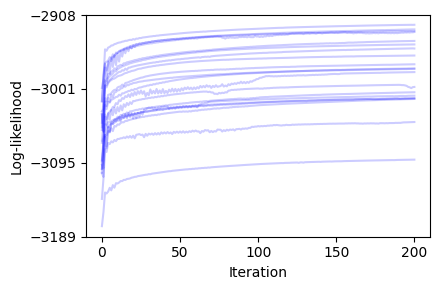

In [64]:
plt.figure(figsize=FIGSIZE)

for params in discrimalign_results_rep:
    plt.plot(
        np.arange(NITER + 1),
        params['loglik_trajectory'],
        alpha=0.2,
        color='b'
    )

plt.xlabel("Iteration")
plt.ylabel("Log-likelihood")

ax = plt.gca()

xmin, xmax = ax.get_xlim()
ax.set_xticks(np.linspace(0, 200, 5, dtype=int))
ax.set_xlim(xmin, xmax)

ax.set_yticks(np.linspace(*ax.get_ylim(), 4, dtype=int))

plt.tight_layout()
plt.savefig("results/general/replicates_loglik_trajectories_general.png", dpi=DPI)

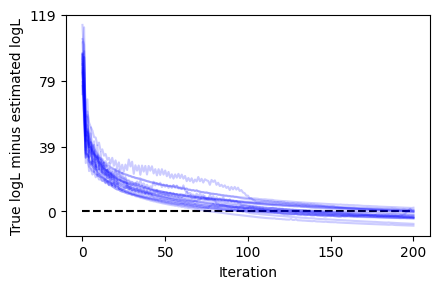

In [65]:
plt.figure(figsize=FIGSIZE)

plt.plot([0, NITER], [0, 0], 'k--')

for params, tlL in zip(discrimalign_results_rep, true_logLs):
    plt.plot(
        np.arange(NITER + 1),
        tlL - np.array(params['loglik_trajectory']),
        alpha=0.2,
        color='b'
    )

plt.xlabel("Iteration")
plt.ylabel("True logL minus estimated logL")

ax = plt.gca()

xmin, xmax = ax.get_xlim()
ax.set_xticks(np.linspace(0, 200, 5, dtype=int))
ax.set_xlim(xmin, xmax)


ymin, ymax = ax.get_ylim()
ax.set_yticks(np.linspace(0, ymax+1, 4, dtype=int))
plt.tight_layout()
plt.savefig("results/general/replicates_loglik_gap_general.png", dpi=DPI)

In [66]:
rep_corrs = []
rep_maes = []

for params in discrimalign_results_rep:
    print(true_gapopen, params['open_gap_score'])
    print(true_gapext, params['extend_gap_score'])
    print(true_alpha, params['alpha'])

    true_subs_vector = []
    param_subs_vector = []

    for char1 in true_substitution.alphabet:
        for char2 in true_substitution.alphabet:
            true_v = true_substitution[char1, char2]
            estim_v = params['substitution_matrix'][char1, char2]

            true_subs_vector.append(true_v)
            param_subs_vector.append(estim_v)

            print(char1, char2, true_v, estim_v)

    true_subs_vector = np.array(true_subs_vector)
    param_subs_vector = np.array(param_subs_vector)

    corr = np.corrcoef(true_subs_vector, param_subs_vector)[0, 1]
    mae = np.mean(np.abs(true_subs_vector - param_subs_vector))

    print(np.corrcoef(true_subs_vector, param_subs_vector))
    print(mae)

    rep_corrs.append(corr)
    rep_maes.append(mae)

rep_corrs = np.array(rep_corrs)
rep_maes = np.array(rep_maes)

-1.2 -1.2372038118661783
-0.1 -0.0971217122795078
-12 -11.758288826696905
A A 1.0 0.9679770142015088
A C -0.3 -0.32798554508769556
A T -1.0 -1.0182532371313586
A G -0.8 -0.7553692578353035
C A -0.6 -0.6637291240323178
C C 1.2 1.187560283884012
C T -0.3 -0.2646349966121609
C G -1.0 -0.861989416966994
T A -1.2 -1.1255919811546542
T C -0.4 -0.42192992664949597
T T 1.0 1.0124477802684704
T G -0.8 -0.7756496887494916
G A -0.4 -0.47153171016868584
G C -1.4 -0.9806976700856151
G T -0.9 -0.8537582120852466
G G 1.3 1.2857596761865757
[[1.       0.992721]
 [0.992721 1.      ]]
0.06605557034852884
-1.2 -1.143513633916548
-0.1 -0.09485173239945481
-12 -11.739980947764192
A A 1.0 0.9899975623932752
A C -0.3 -0.24946845173817805
A T -1.0 -0.7989695733286434
A G -0.8 -0.6714257006473819
C A -0.6 -0.594469322229207
C C 1.2 1.1619412323296165
C T -0.3 -0.27552181636995154
C G -1.0 -0.9371000422467883
T A -1.2 -1.0001836847502663
T C -0.4 -0.42804590547072735
T T 1.0 0.958672037794885
T G -0.8 -0.743449

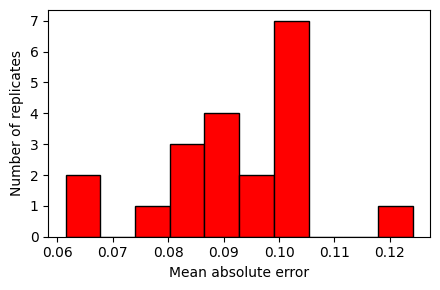

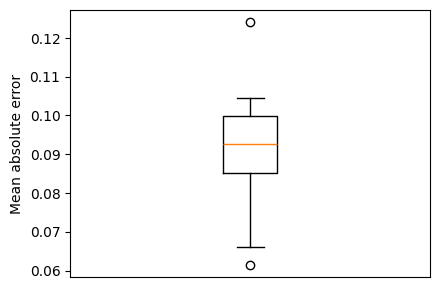

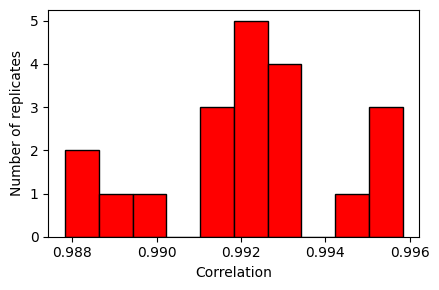

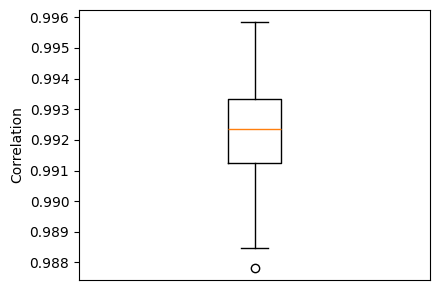

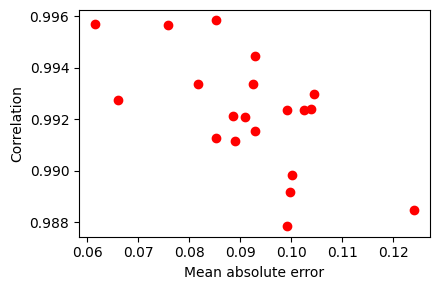

In [67]:
plt.figure(figsize=FIGSIZE)
plt.hist(rep_maes, bins=10, edgecolor = 'black', color = 'red')
plt.xlabel("Mean absolute error")
plt.ylabel("Number of replicates")
plt.tight_layout()
plt.savefig("results/general/replicates_mae_histogram_general.png", dpi=DPI)
plt.show()

plt.figure(figsize=FIGSIZE)
plt.boxplot(rep_maes)
plt.ylabel("Mean absolute error")
plt.xticks([])
plt.tight_layout()
plt.savefig("results/general/replicates_mae_boxplot_general.png", dpi=DPI)
plt.show()

plt.figure(figsize=FIGSIZE)
plt.hist(rep_corrs, bins=10, edgecolor = 'black', color = 'red')
plt.xlabel("Correlation")
plt.ylabel("Number of replicates")
plt.tight_layout()
plt.savefig("results/general/replicates_correlation_histogram_general.png", dpi=DPI)
plt.show()

plt.figure(figsize=FIGSIZE)
plt.boxplot(rep_corrs)
plt.ylabel("Correlation")
plt.xticks([])
plt.tight_layout()
plt.savefig("results/general/replicates_correlation_boxplot_general.png", dpi=DPI)
plt.show()

plt.figure(figsize=FIGSIZE)
plt.scatter(rep_maes, rep_corrs, color = 'red')
plt.xlabel("Mean absolute error")
plt.ylabel("Correlation")
plt.tight_layout()
plt.savefig("results/general/replicates_mae_vs_correlation_scatter_general.png", dpi=DPI)
plt.show()